In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from spectral_method_utils import findFWHM, semi_analytical_asm, angular_spectrum_method

In [2]:
params = {}
with open("/home/karthik/Desktop/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params[item[0]] = float(item[1])
n0 = params["n0_real"] + 1j*params["n0_imag"]
n2 = params["n2_real"] + 1j*params["n2_imag"]
n2 *= 1e6
wavelength_0 = params["wavelength"] * 1e-3
wavelength = wavelength_0 / n0.real
steps = int(params["steps"])
levelFFT = int(params["levelFFT"])
typ = params["typ"]
zScreen = params["zScreen"] * 1e-3
radiusGeo = params["radiusGeo"] * 1e-3
SG = params["SG"]
material = params["material"]
angle = params["angle"]
zw = params["zw"] * 1e-3
step = zScreen/steps


In [3]:
angle = np.asin(np.sin(angle)/n0.real)
w0 = wavelength / (np.pi * np.tan(angle))
a = -zw
b = np.pi * w0 * w0 / wavelength #wavelength / (M_PI * tan(angleRad) * tan(angleRad))   #Rayleigh length
R = (a*a+b*b)/a                                       #Radius of curvature
wavenumber =  2.0 * np.pi * n0 / wavelength_0  
w = np.sqrt(2.0 * (a*a+b*b) / (b * wavenumber.real))          #Beam radius
wSG = w
length = 2**levelFFT
h = 2*radiusGeo / length
x = np.linspace(-radiusGeo, radiusGeo-h, int(2**levelFFT))
y = np.linspace(-radiusGeo, radiusGeo-h, int(2**levelFFT))
xx, yy = np.meshgrid(x,y)

print(f"a={a}, b={b}, w0={w0}, w={w}, R={R}, levelFFT={levelFFT}, n0={n0}, n2={n2}")

a=0.002, b=2.1675629699113257, w0=0.000677363432948198, w=0.0006773637212903962, R=2349.166614265403, levelFFT=6, n0=(1.6+0j), n2=0j


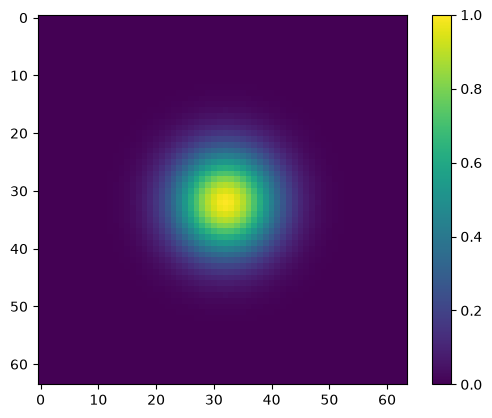

In [4]:
E = np.exp(-(np.sqrt(xx*xx + yy*yy) / wSG)**SG)
E = E* np.exp(-1j*wavenumber * (xx*xx + yy*yy) / (2*R))
powerField = np.abs(E**2)
plt.imshow(powerField)
plt.colorbar()
plt.show()

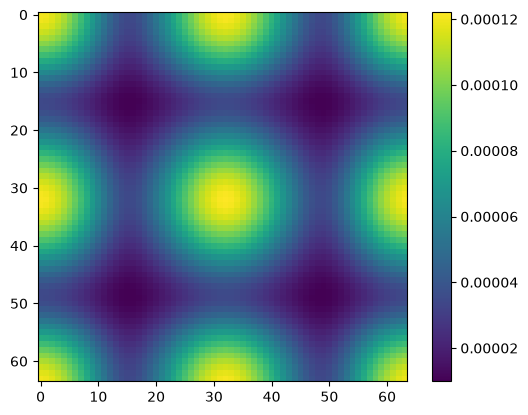

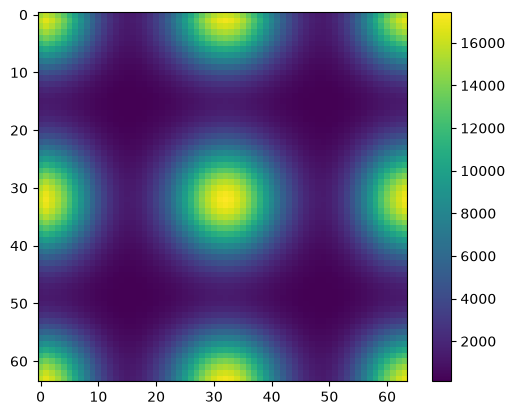

In [5]:
k2 = wavenumber*wavenumber
dx = radiusGeo*2 / (2**levelFFT)
E = semi_analytical_asm(E, step, k2, length, dx, xx, yy)
powerField = np.abs(E**2)
plt.imshow(powerField)
plt.colorbar()
plt.show()

In [ ]:
func = np.atan2(E.imag, E.real)
fxx = (func[length//2+1,length//2] - 2*func[length//2,length//2] + func[length//2-1,length//2])/(x[length//2+1]**2)
fyy = (func[length//2,length//2+1] - 2*func[length//2,length//2] + func[length//2,length//2-1])/(y[length//2+1]**2)
fxy = (func[length//2+1,length//2+1] - func[length//2+1,length//2-1] - func[length//2-1,length//2+1] + func[length//2-1,length//2-1])/(4*x[length//2+1]*y[length//2+1])
taylor = 0.5*fxx*xx*xx + fxy*xx*yy + 0.5*fyy*yy*yy
print(fxx/2,fyy/2,fxy)

112259.43928061756 112259.43928180546 -8.909335854102138e-07


In [95]:
func[length//2+1,length//2]

np.float64(-1.6278741931924776)

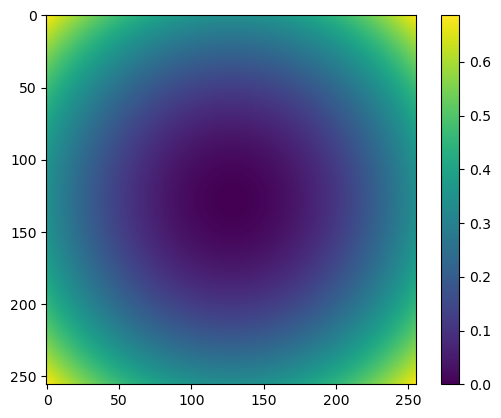

In [98]:
plt.imshow(taylor)
plt.colorbar()

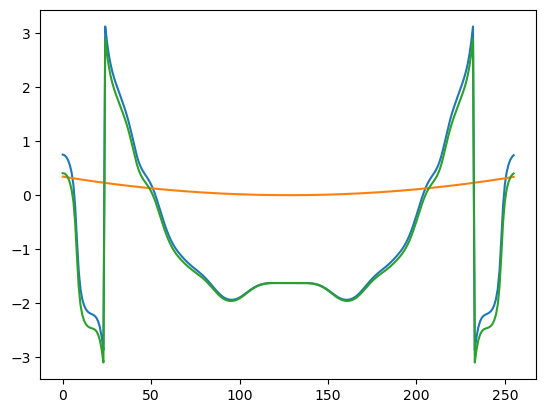

In [103]:
plt.plot(func[length//2])
plt.plot(taylor[length//2])
plt.plot(func[length//2] - taylor[length//2])
plt.show()

In [18]:
fwhms = np.zeros(steps+1)
intensities = np.zeros(steps+1)

dx = radiusGeo*2 / (2**levelFFT)
fwhm, intensity = findFWHM(powerField, dx)
fwhms[0] = fwhm
intensities[0] = intensity

wavenumber = 2*np.pi*n0 / wavelength_0
# k2 = wavenumber*wavenumber - (wavenumber * wavenumber * n2 *(xx*xx + yy*yy) / n0)
k2 = wavenumber*wavenumber
for i in range(1, steps+1):
    E = angular_spectrum_method(E, step, k2, int(2**levelFFT), dx)
    powerField = np.abs(E**2)
    fwhm, intensity = findFWHM(powerField, dx)
    fwhms[i] = fwhm
    intensities[i] = intensity

NameError: name 'scipy' is not defined

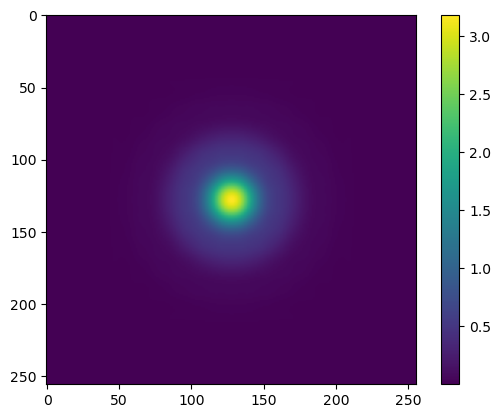

In [ ]:
plt.imshow(powerField)
plt.colorbar()
plt.show()

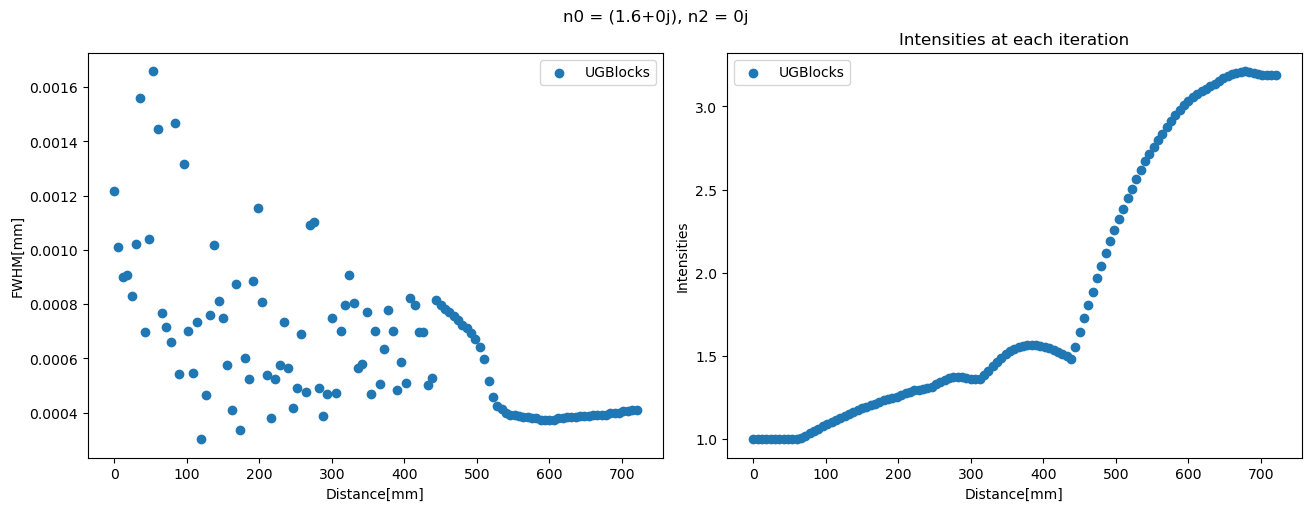

In [81]:
end = zScreen*1e3 + 1
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
axes[0].scatter(np.arange(0, end, step*1e3), fwhms[0::1], label="UGBlocks")
axes[0].set_ylabel("FWHM[mm]")
axes[0].set_xlabel("Distance[mm]")
# axes[0].set_xticks(np.arange(0, end, end//12))
axes[0].legend()

axes[1].scatter(np.arange(0, end, step*1e3), intensities[0::1], label="UGBlocks")
axes[1].set_ylabel("Intensities")
axes[1].set_xlabel("Distance[mm]")
# axes[1].set_xticks(np.arange(0, end, end//12))
axes[1].set_title("Intensities at each iteration")
axes[1].legend()

plt.suptitle(f"n0 = {n0}, n2 = {n2}")

plt.show()